In [74]:
import numpy as np
import pandas as pd

# Load file
df_raw = pd.read_csv("AeroCardia_RestingBaselineData.csv")

# Remove rows that are fully blank or where all values are null
df_raw = df_raw.dropna(how='all')

#drop columns where all values are null
df_raw = df_raw.dropna(axis=1, how="all")

# Reset index
df = df_raw.reset_index(drop=True)

# Rename columns
df.columns = ["Elapsed Time", "Timestamp", "Ambient Temp", "Ambient Humidity", "Heart Rate", "SpO2", "Lung Volume", "O2", "CO2", "RER", "Pressure BMP A", "Pressure BMP B", "Pressure BMP C Ambient", "Pressure Diff A-C (Pa)",	"Pressure Diff B-C (Pa)",
 "Temp BMP A","Temp BMP B","Temp BMP C", "IMU X", "IMU Y", "IMU Z", "BMI Gyro X", "BMI Gyro Y", "BMI Gyro Z", "PPG IR", "PPG Red", "Battery State"]

df.head()


,Elapsed Time,Timestamp,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
0,0,2026-02-02T17:27:41.274Z,28.076,47.459,NaN,NaN,4.5,20.226,0,0.7,...,32.387,0.139,-0.307,0.898,230,45,-86,105625,85832,0
1,91,2026-02-02T17:27:41.365Z,28.129,47.459,NaN,NaN,4.5,20.226,0,0.7,...,32.383,0.150,-0.303,0.923,-26,-155,-7,110983,88298,0
2,227,2026-02-02T17:27:41.501Z,28.129,53.525,NaN,NaN,4.5,20.226,0,0.7,...,32.391,0.144,-0.333,0.923,117,-16,-163,110983,88298,0
3,317,2026-02-02T17:27:41.591Z,28.183,53.525,NaN,NaN,4.5,20.226,0,0.7,...,32.390,0.144,-0.315,0.924,-54,-98,158,111385,88470,0
4,414,2026-02-02T17:27:41.688Z,28.161,58.163,NaN,NaN,4.5,20.226,0,0.7,...,32.392,0.153,-0.292,0.919,8,-72,-17,111385,88470,0


In [75]:
#count the number of null values in heart rate
df["Heart Rate"].isnull().sum()

np.int64(30)

In [76]:
#count the number of null values in SpO2
df["SpO2"].isnull().sum()

np.int64(30)

Need to decide method of cleaning for nulls - regarding below

In [77]:
#fill null values in heart rate with the mean
#df["Heart Rate"] = df["Heart Rate"].fillna(df["Heart Rate"].mean())
#fill null values in SpO2 with the mean
#df["SpO2"] = df["SpO2"].fillna(df["SpO2"].mean())
#rename df to df_cleaned

#fill nulls with median
# df["column"] = df["column"].fillna(df["column"].median())

In [78]:
#fill null values in heart rate column with zeros
df["Heart Rate"] = df["Heart Rate"].fillna(0)
#fill null values in SpO2 column with zeros
df["SpO2"] = df["SpO2"].fillna(0)

In [79]:
df_cleaned = df

In [80]:
df_cleaned.describe()

,Elapsed Time,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,Pressure BMP A,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
count,360.000000,360.000000,360.000000,360.000000,360.00000,360.0,360.000000,360.0,3.600000e+02,360.000000,...,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.0
mean,17951.794444,28.191072,64.003856,58.177778,89.35000,4.5,18.998294,0.0,7.000000e-01,100866.949528,...,32.716036,0.102742,-0.134797,0.946100,62.052778,-41.241667,-15.336111,78135.463889,71990.725000,0.0
std,10408.072532,0.056640,9.278139,23.951007,26.98498,0.0,0.440536,0.0,4.558250e-15,230.321800,...,0.191624,0.054234,0.193099,0.045515,404.761080,389.140206,568.142633,27213.979750,23082.985371,0.0
min,0.000000,28.054000,44.652000,0.000000,0.00000,4.5,18.537000,0.0,7.000000e-01,100490.188000,...,32.383000,-0.247000,-0.374000,0.596000,-1181.000000,-3504.000000,-4385.000000,0.000000,0.000000,0.0
25%,8977.750000,28.151000,56.194750,50.000000,97.00000,4.5,18.664000,0.0,7.000000e-01,100631.187500,...,32.549500,0.100000,-0.196000,0.946000,-45.000000,-34.250000,-46.250000,72192.750000,70300.750000,0.0
50%,17955.000000,28.194000,64.412000,57.000000,98.00000,4.5,18.855000,0.0,7.000000e-01,100856.640500,...,32.720000,0.110500,-0.182000,0.958000,14.000000,3.000000,7.500000,82748.000000,80427.500000,0.0
75%,26933.000000,28.236000,72.250750,69.000000,98.00000,4.5,19.142000,0.0,7.000000e-01,101104.015500,...,32.879500,0.122000,-0.167000,0.965000,75.500000,41.500000,61.000000,90553.000000,84683.750000,0.0
max,35908.000000,28.311000,82.318000,120.000000,98.00000,4.5,20.226000,0.0,7.000000e-01,101209.609000,...,33.080000,0.208000,0.642000,1.011000,3116.000000,1335.000000,3551.000000,111984.000000,88802.000000,0.0


In [81]:
#find the median for all numeric columns in the dataset
df_cleaned.median(numeric_only=True)

,0
Elapsed Time,17955.0000
Ambient Temp,28.1940
Ambient Humidity,64.4120
Heart Rate,57.0000
SpO2,98.0000
Lung Volume,4.5000
O2,18.8550
CO2,0.0000
RER,0.7000
Pressure BMP A,100856.6405


In [82]:
#find one mode for all numeric columns in the dataset
df_cleaned.select_dtypes(include="number").mode().iloc[0]

,0
Elapsed Time,0.000
Ambient Temp,28.215
Ambient Humidity,53.525
Heart Rate,49.000
SpO2,98.000
Lung Volume,4.500
O2,18.664
CO2,0.000
RER,0.700
Pressure BMP A,100613.469


In [83]:
#find correlations between columns - default correlation method Pearson correlation
df_cleaned["Ambient Temp"].corr(df_cleaned["Heart Rate"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Heart Rate"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Heart Rate"])


np.float64(0.1469755731749781)

In [84]:

#df_cleaned["Ambient Temp"].corr(df_cleaned["Lung Volume"])
#df_cleaned["Ambient Humidity"].corr(df_cleaned["Lung Volume"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Lung Volume"])

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



np.float64(nan)

In [85]:
df_cleaned["Ambient Temp"].corr(df_cleaned["O2"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["O2"])
df_cleaned["Elapsed Time"].corr(df_cleaned["O2"])

np.float64(-0.8170003227185066)

In [86]:
df_cleaned["Ambient Temp"].corr(df_cleaned["Pressure BMP A"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Pressure BMP A"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Pressure BMP A"])


np.float64(0.26672295671616786)

In [87]:
df_cleaned["Ambient Temp"].corr(df_cleaned["Pressure BMP B"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Pressure BMP B"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Pressure BMP B"])

np.float64(-0.12962716818643363)

In [88]:
df_cleaned["Ambient Temp"].corr(df_cleaned["Pressure BMP C Ambient"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Pressure BMP C Ambient"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Pressure BMP C Ambient"])

np.float64(0.33898663899151543)

In [89]:
df_cleaned["Ambient Temp"].corr(df_cleaned["BMI Gyro X"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["BMI Gyro Y"])
df_cleaned["Elapsed Time"].corr(df_cleaned["BMI Gyro Z"])

np.float64(-0.07993733429721102)

In [90]:
df_cleaned["Ambient Temp"].corr(df_cleaned["Temp BMP A"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Temp BMP A"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Temp BMP A"])

np.float64(0.9837648027968839)

In [91]:
df_cleaned["Ambient Temp"].corr(df_cleaned["Temp BMP B"])
df_cleaned["Ambient Humidity"].corr(df_cleaned["Temp BMP B"])
df_cleaned["Elapsed Time"].corr(df_cleaned["Temp BMP B"])

np.float64(0.994726862759206)

In [92]:
#find correlations between all columns - default correlation method Pearson correlation
df_cleaned.corr(numeric_only=True)

,Elapsed Time,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,Pressure BMP A,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
Elapsed Time,1.000000,0.726331,-0.303142,0.146976,0.492611,NaN,-0.817000,NaN,NaN,0.266723,...,0.999338,-0.312406,0.559528,-0.297389,0.123856,-0.201580,-0.079937,-0.607443,-0.407954,NaN
Ambient Temp,0.726331,1.000000,0.197607,0.279852,0.429042,NaN,-0.526085,NaN,NaN,-0.395973,...,0.723697,-0.156130,0.341012,-0.114217,0.051582,-0.122339,-0.027556,-0.293550,-0.164591,NaN
Ambient Humidity,-0.303142,0.197607,1.000000,0.243080,0.100334,NaN,0.110045,NaN,NaN,-0.659588,...,-0.306906,0.364700,-0.470286,0.430369,-0.182289,0.189451,0.144905,0.526939,0.511138,NaN
Heart Rate,0.146976,0.279852,0.243080,1.000000,0.732324,NaN,-0.289609,NaN,NaN,-0.129088,...,0.142128,-0.079253,-0.004014,0.236826,-0.058144,0.006821,0.030396,0.098672,0.119188,NaN
SpO2,0.492611,0.429042,0.100334,0.732324,1.000000,NaN,-0.710012,NaN,NaN,0.030453,...,0.491444,-0.207688,0.262672,0.121747,-0.000684,-0.073234,-0.000061,-0.318135,-0.175840,NaN
Lung Volume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O2,-0.817000,-0.526085,0.110045,-0.289609,-0.710012,NaN,1.000000,NaN,NaN,-0.261323,...,-0.814408,0.080131,-0.214995,-0.067816,-0.063378,0.052820,-0.058306,0.400808,0.114578,NaN
CO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure BMP A,0.266723,-0.395973,-0.659588,-0.129088,0.030453,NaN,-0.261323,NaN,NaN,1.000000,...,0.270470,-0.247304,0.291799,-0.262488,0.126831,-0.108343,-0.019858,-0.418404,-0.368363,NaN


Pearson Correlation Summary - with nulls as mean



*   elapsed time and ambient temp have high positive correlation 0.726331

*   elapsed time and temp bmp a have a high positive correlation 0.983765

*   elapsed time and temp bmp b have a high positive correlation 0.994727

*   elapsed time and temp bmp c have a high positive correlation 0.999338

*   ambient temp and temp bmp a have a high positive correlation 0.789956

*   ambient temp and temp bmp b have a high positive correlation 0.736839

*   ambient temp and temp bmp c have a high positive correlation 0.723697

*   PPG IR and elapsed time have a strong negative correlation -0.607443

*   PPG Red and IMU Z have a strong/high positive correlation 0.654478

*   PPG Red and PPG IR have a strong positive correlation 0.942417



In [93]:
#other correlation methods
#df["col1"].corr(df["col2"], method="spearman")
#df["col1"].corr(df["col2"], method="kendall")
#df.corr(method="spearman", numeric_only=True)
#df.corr(method="kendall", numeric_only=True)

🔹 Pearson Correlation (baseline)
What it measures: Linear relationship between two variables (do they move together in a straight-line way).
Key idea: Uses actual values and distances between them.

👉 Example: If prices go up steadily each year → high Pearson correlation.

🔹 Spearman Correlation (rank-based)
What it measures: Whether two variables move in the same order/ranking, not necessarily linearly.
Key idea: Converts values to ranks (1st, 2nd, 3rd…) and then checks correlation.

👉 Example: Even if growth is curved (not straight), as long as values consistently increase, Spearman will be high.

🔹 Kendall Correlation (rank agreement)
What it measures: How consistently pairs of values move in the same direction (agreement between rankings).
Key idea: Looks at pairs of observations and counts how often they are in the same order.

👉 Example: If most data pairs move together (up/up or down/down), Kendall will be high.

In [94]:
#Spearman (rank-based)
df_cleaned.corr(method="spearman", numeric_only=True)

,Elapsed Time,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,Pressure BMP A,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
Elapsed Time,1.000000,0.736129,-0.284788,0.059036,0.786153,NaN,-0.820945,NaN,NaN,0.259605,...,0.999933,-0.105041,0.574670,-0.081056,-0.041349,-0.144379,-0.089292,-0.462598,-0.113100,NaN
Ambient Temp,0.736129,1.000000,0.177391,0.116732,0.612448,NaN,-0.513997,NaN,NaN,-0.348628,...,0.736210,0.014853,0.538818,-0.007088,-0.057748,-0.119533,-0.067956,-0.095654,0.155807,NaN
Ambient Humidity,-0.284788,0.177391,1.000000,0.247438,-0.152224,NaN,0.167719,NaN,NaN,-0.656818,...,-0.284678,0.215466,-0.072784,0.317682,-0.174590,0.202280,0.170146,0.385806,0.296714,NaN
Heart Rate,0.059036,0.116732,0.247438,1.000000,0.284734,NaN,-0.315319,NaN,NaN,-0.095647,...,0.059105,-0.095950,-0.105716,0.366227,-0.098780,-0.082045,0.090354,0.225679,0.234932,NaN
SpO2,0.786153,0.612448,-0.152224,0.284734,1.000000,NaN,-0.721472,NaN,NaN,0.177066,...,0.786158,-0.144275,0.464083,0.054189,-0.053334,-0.127386,-0.019032,-0.206956,0.070612,NaN
Lung Volume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O2,-0.820945,-0.513997,0.167719,-0.315319,-0.721472,NaN,1.000000,NaN,NaN,-0.275456,...,-0.820950,0.008273,-0.353219,-0.175240,0.034719,0.063559,-0.087336,0.321217,-0.080367,NaN
CO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure BMP A,0.259605,-0.348628,-0.656818,-0.095647,0.177066,NaN,-0.275456,NaN,NaN,1.000000,...,0.259946,-0.199519,-0.033624,-0.196729,0.053797,0.012838,0.035476,-0.400216,-0.346583,NaN


In [95]:
#Kendall (rank-based, more robust)
df_cleaned.corr(method="kendall", numeric_only=True)

,Elapsed Time,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,Pressure BMP A,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
Elapsed Time,1.000000,0.543690,-0.204894,0.003765,0.652274,NaN,-0.701670,NaN,NaN,0.185673,...,0.995092,-0.052404,0.434067,-0.044483,-0.031640,-0.101720,-0.058349,-0.298388,-0.054332,NaN
Ambient Temp,0.543690,1.000000,0.119736,0.050269,0.510429,NaN,-0.360587,NaN,NaN,-0.243688,...,0.544162,0.013601,0.388485,-0.002185,-0.044644,-0.081737,-0.050744,-0.033995,0.116148,NaN
Ambient Humidity,-0.204894,0.119736,1.000000,0.168942,-0.116510,NaN,0.117447,NaN,NaN,-0.469242,...,-0.204708,0.148152,-0.040008,0.218529,-0.123029,0.145821,0.115468,0.276037,0.202950,NaN
Heart Rate,0.003765,0.050269,0.168942,1.000000,0.228618,NaN,-0.220171,NaN,NaN,-0.067071,...,0.003848,-0.069157,-0.107803,0.243930,-0.067715,-0.059493,0.059642,0.184675,0.200300,NaN
SpO2,0.652274,0.510429,-0.116510,0.228618,1.000000,NaN,-0.601508,NaN,NaN,0.136275,...,0.652668,-0.116164,0.375761,0.049164,-0.042951,-0.100221,-0.014477,-0.165348,0.075496,NaN
Lung Volume,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O2,-0.701670,-0.360587,0.117447,-0.220171,-0.601508,NaN,1.000000,NaN,NaN,-0.198100,...,-0.701779,-0.000143,-0.254201,-0.119054,0.023904,0.044021,-0.058584,0.212017,-0.052605,NaN
CO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure BMP A,0.185673,-0.243688,-0.469242,-0.067071,0.136275,NaN,-0.198100,NaN,NaN,1.000000,...,0.185568,-0.136632,-0.024743,-0.131577,0.039914,0.007214,0.019264,-0.288932,-0.231457,NaN


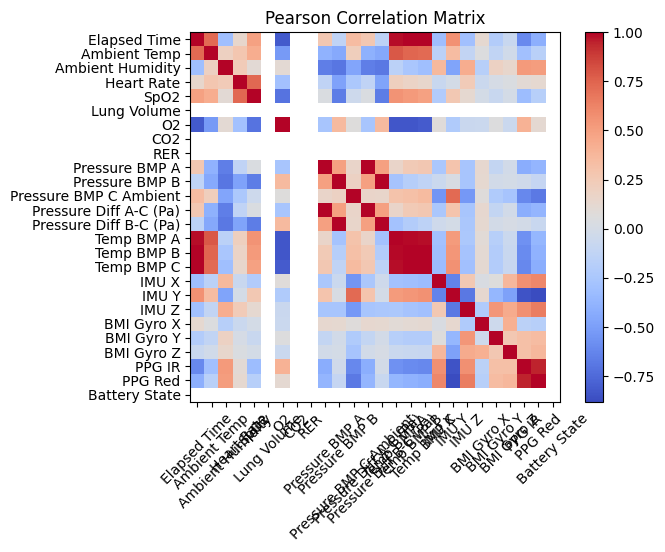

In [96]:
#correlation matrix
import matplotlib.pyplot as plt

corr = df_cleaned.corr(numeric_only=True)

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Pearson Correlation Matrix")
plt.show()

In [97]:
#interactive heatmap
import plotly.express as px

corr = df_cleaned.corr(numeric_only=True)

fig = px.imshow(corr, text_auto=True, title="Pearson Correlation Matrix")
fig.show()

In [98]:
corr_pearson = df_cleaned.corr(numeric_only=True)
corr_spearman = df_cleaned.corr(method="spearman", numeric_only=True)
corr_kendall = df_cleaned.corr(method="kendall", numeric_only=True)

In [99]:
import plotly.express as px

fig = px.imshow(corr_spearman, text_auto=True, title="Spearman Correlation")
fig.show()

In [100]:
import plotly.express as px

fig = px.imshow(corr_kendall, text_auto=True, title="Kendall Correlation")
fig.show()

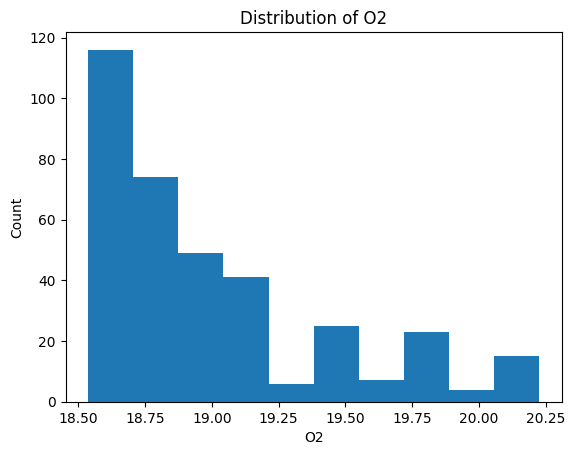

In [101]:
#histograms
import matplotlib.pyplot as plt

plt.hist(df_cleaned["O2"], bins=10)
plt.title("Distribution of O2")
plt.xlabel("O2")
plt.ylabel("Count")
plt.show()

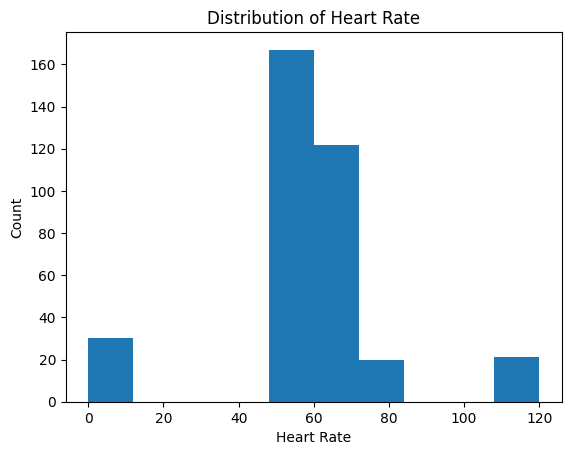

In [102]:
import matplotlib.pyplot as plt

plt.hist(df_cleaned["Heart Rate"], bins=10)
plt.title("Distribution of Heart Rate")
plt.xlabel("Heart Rate")
plt.ylabel("Count")
plt.show()

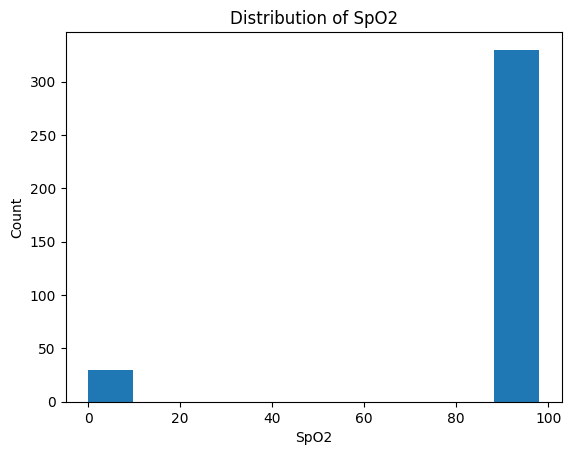

In [103]:
import matplotlib.pyplot as plt

plt.hist(df_cleaned["SpO2"], bins=10)
plt.title("Distribution of SpO2")
plt.xlabel("SpO2")
plt.ylabel("Count")
plt.show()

In [104]:
#interactive histogram
import plotly.express as px

fig = px.histogram(
    df_cleaned,
    x="O2",
    nbins=10,
    title="Distribution of O2"
)

fig.show()

In [105]:
#distro of BMI Gyro X histogram
import plotly.express as px

fig = px.histogram(
    df_cleaned,
    x="BMI Gyro X",
    nbins=10,
    title="Distribution of BMI Gyro X"
)

fig.show()

In [106]:
import plotly.express as px

fig = px.line(
    df_cleaned,
    x="Elapsed Time",
    y="Temp BMP A",
    title="Temp BMP A by Elapsed Time",
    markers=True
)

fig.show()

In [107]:
import plotly.express as px

fig = px.line(
    df_cleaned,
    x="Elapsed Time",
    y="Temp BMP B",
    title="Temp BMP B by Elapsed Time",
    markers=True
)
fig.update_traces(line=dict(color="#1f77b4"))
fig.show()

In [108]:
import plotly.express as px

fig = px.line(
    df_cleaned,
    x="Temp BMP C",
    y="O2",
    title="O2 by Temp BMP C",
    markers=True
)
fig.update_traces(line=dict(color="#1f77b4"))
fig.show()

In [109]:
import plotly.express as px

fig = px.line(
    df_cleaned,
    x="Temp BMP B",
    y="O2",
    title="O2 by Temp BMP B",
    markers=True
)
fig.update_traces(line=dict(color="#1f77b4"))
fig.show()

In [110]:
import plotly.express as px

fig = px.line(
    df_cleaned,
    x="Temp BMP A",
    y="O2",
    title="O2 by Temp BMP A",
    markers=True
)
fig.update_traces(line=dict(color="#1f77b4"))
fig.show()

In [111]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="Ambient Temp",
    y="Heart Rate",
    title="Scatter Plot - Heart Rate & Ambient Temp"
)

fig.show()


In [112]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="O2",
    y="Temp BMP A",
    title="Scatter Plot - O2 & Temp BMP A"
)

fig.show()

In [113]:
df_cleaned.head()

,Elapsed Time,Timestamp,Ambient Temp,Ambient Humidity,Heart Rate,SpO2,Lung Volume,O2,CO2,RER,...,Temp BMP C,IMU X,IMU Y,IMU Z,BMI Gyro X,BMI Gyro Y,BMI Gyro Z,PPG IR,PPG Red,Battery State
0,0,2026-02-02T17:27:41.274Z,28.076,47.459,0.0,0.0,4.5,20.226,0,0.7,...,32.387,0.139,-0.307,0.898,230,45,-86,105625,85832,0
1,91,2026-02-02T17:27:41.365Z,28.129,47.459,0.0,0.0,4.5,20.226,0,0.7,...,32.383,0.150,-0.303,0.923,-26,-155,-7,110983,88298,0
2,227,2026-02-02T17:27:41.501Z,28.129,53.525,0.0,0.0,4.5,20.226,0,0.7,...,32.391,0.144,-0.333,0.923,117,-16,-163,110983,88298,0
3,317,2026-02-02T17:27:41.591Z,28.183,53.525,0.0,0.0,4.5,20.226,0,0.7,...,32.390,0.144,-0.315,0.924,-54,-98,158,111385,88470,0
4,414,2026-02-02T17:27:41.688Z,28.161,58.163,0.0,0.0,4.5,20.226,0,0.7,...,32.392,0.153,-0.292,0.919,8,-72,-17,111385,88470,0


In [114]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="O2",
    y="BMI Gyro X",
    title="Scatter Plot - O2 & BMI Gyro X"
)

fig.show()

In [115]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="O2",
    y="BMI Gyro Y",
    title="Scatter Plot - O2 & BMI Gyro Y"
)

fig.show()

In [116]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="Heart Rate",
    y="BMI Gyro X",
    title="Scatter Plot - Heart Rate & BMI Gyro X"
)

fig.update_traces(
    marker=dict(
        size=10,
        color="#1f77b4",
        opacity=0.7
    )
)

fig.show()

In [117]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="Heart Rate",
    y="BMI Gyro Y",
    title="Scatter Plot - Heart Rate & BMI Gyro Y"
)

fig.update_traces(
    marker=dict(
        size=10,
        color="#1f77b4",
        opacity=0.8
    )
)

fig.show()

In [118]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['PPG Red'])  # adds intercept
y = df_cleaned['IMU Z']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())
# r-squared of 0.428 indicates a weaker model

                            OLS Regression Results                            
Dep. Variable:                  IMU Z   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     268.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.16e-45
Time:                        18:43:59   Log-Likelihood:                 702.64
No. Observations:                 360   AIC:                            -1401.
Df Residuals:                     358   BIC:                            -1394.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8532      0.006    143.250      0.0

In [119]:
r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"PPG Red and IMU Z produces a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"PPG Red and IMU Z produces a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"PPG Red and IMU Z produces a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

R-squared: 0.42834107542583055
PPG Red and IMU Z produces a moderate model with an r-squared value of 0.42834107542583055


In [120]:
#linear regression scikit learn method

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[["PPG Red"]]
y = df["IMU Z"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # reproducibility
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

[0.96462529 0.96282228 0.96124974 0.96405366 0.95934844 0.95820631
 0.96173664 0.95934844 0.96233877 0.94891222 0.94847729 0.86664482
 0.94946804 0.86664482 0.93869856 0.94702787 0.95623045 0.96395312
 0.94353144 0.86664482 0.94353144 0.96376898 0.96405818 0.96325835
 0.96086225 0.96362325 0.93818793 0.96405818 0.96057304 0.95579552
 0.95258602 0.96661471 0.86664482 0.93818793 0.93885784 0.96292057
 0.96008727 0.86664482 0.9365894  0.93811789 0.94464194 0.96105656
 0.96068601 0.93753948 0.95359033 0.96231505 0.96208459 0.96658985
 0.96281664 0.86664482 0.9542241  0.95197937 0.94946804 0.95268996
 0.86664482 0.95918124 0.96658985 0.94078738 0.95268996 0.96124974
 0.95572774 0.96245174 0.96407287 0.95268996 0.95612539 0.94346591
 0.86664482 0.95714777 0.86664482 0.93444183 0.95925581 0.95925581]


In [121]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

     Actual  Predicted
224   0.955   0.964625
42    0.955   0.962822
285   0.936   0.961250
302   0.940   0.964054
56    0.947   0.959348


In [122]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [1.12970541e-06]
Intercept: 0.8666448152868593


In [123]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.43688109817627574


In [124]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['PPG Red'])  # adds intercept
model = sm.OLS(df_cleaned['PPG IR'], X).fit() # defines and fits regression model

print(model.summary())
# r-squared of 0.888 indicates a stronger model

                            OLS Regression Results                            
Dep. Variable:                 PPG IR   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     2843.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          2.27e-172
Time:                        18:43:59   Log-Likelihood:                -3792.1
No. Observations:                 360   AIC:                             7588.
Df Residuals:                     358   BIC:                             7596.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1851.6045   1575.241     -1.175      0.2

In [125]:
r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"PPG Red and PPG IR produces a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"PPG Red and PPG IR produces a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"PPG Red and PPG IR produces a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

R-squared: 0.8881499656237919
PPG Red and PPG IR produces a strong model with an r-squared value of 0.8881499656237919


In [126]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Elapsed Time'])  # adds intercept
y = df_cleaned['Temp BMP A']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Elapsed Time and Temp BMP A produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Elapsed Time and Temp BMP A produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Elapsed Time and Temp BMP A produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP A   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 1.076e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          3.58e-269
Time:                        18:43:59   Log-Likelihood:                 1209.3
No. Observations:                 360   AIC:                            -2415.
Df Residuals:                     358   BIC:                            -2407.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           28.0204      0.001   3.16e+04   

In [127]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Elapsed Time'])  # adds intercept
y = df_cleaned['Temp BMP B']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Elapsed Time and Temp BMP B produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Elapsed Time and Temp BMP B produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Elapsed Time and Temp BMP B produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP B   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 3.368e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:43:59   Log-Likelihood:                 1471.8
No. Observations:                 360   AIC:                            -2940.
Df Residuals:                     358   BIC:                            -2932.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           27.8570      0.000   6.51e+04   

In [128]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Elapsed Time'])  # adds intercept
y = df_cleaned['Temp BMP C']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Elapsed Time and Temp BMP C produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Elapsed Time and Temp BMP C produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Elapsed Time and Temp BMP C produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP C   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.702e+05
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:43:59   Log-Likelihood:                 1277.5
No. Observations:                 360   AIC:                            -2551.
Df Residuals:                     358   BIC:                            -2543.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           32.3857      0.001   4.41e+04   

In [129]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Ambient Temp'])  # adds intercept
y = df_cleaned['Temp BMP A']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Ambient Temp and Temp BMP A produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Ambient Temp and Temp BMP A produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Ambient Temp and Temp BMP A produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP A   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     594.2
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           4.77e-78
Time:                        18:43:59   Log-Likelihood:                 766.95
No. Observations:                 360   AIC:                            -1530.
Df Residuals:                     358   BIC:                            -1522.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.6433      0.757     12.736   

In [130]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Ambient Temp'])  # adds intercept
y = df_cleaned['Temp BMP B']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Ambient Temp and Temp BMP B produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Ambient Temp and Temp BMP B produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Ambient Temp and Temp BMP B produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP B   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     425.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           7.81e-63
Time:                        18:43:59   Log-Likelihood:                 792.87
No. Observations:                 360   AIC:                            -1582.
Df Residuals:                     358   BIC:                            -1574.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.3958      0.705     19.013   

In [131]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Ambient Temp'])  # adds intercept
y = df_cleaned['Temp BMP C']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Ambient Temp and Temp BMP C produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Ambient Temp and Temp BMP C produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Ambient Temp and Temp BMP C produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP C   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     393.7
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.25e-59
Time:                        18:43:59   Log-Likelihood:                 218.00
No. Observations:                 360   AIC:                            -432.0
Df Residuals:                     358   BIC:                            -424.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -36.3070      3.479    -10.437   

In [132]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Elapsed Time'])  # adds intercept
y = df_cleaned['PPG IR']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Elapsed Time and PPG IR produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Elapsed Time and PPG IR produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Elapsed Time and PPG IR produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                 PPG IR   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     209.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.11e-37
Time:                        18:43:59   Log-Likelihood:                -4103.6
No. Observations:                 360   AIC:                             8211.
Df Residuals:                     358   BIC:                             8219.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.066e+05   2277.100     46.835   

In [133]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Heart Rate'])  # adds intercept
y = df_cleaned['O2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Heart Rate and O2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Heart Rate and O2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Heart Rate and O2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                     O2   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     32.78
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.19e-08
Time:                        18:43:59   Log-Likelihood:                -199.43
No. Observations:                 360   AIC:                             402.9
Df Residuals:                     358   BIC:                             410.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.3082      0.059    329.899      0.0

In [134]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Heart Rate'])  # adds intercept
y = df_cleaned['SpO2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Heart Rate and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Heart Rate and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Heart Rate and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                   SpO2   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     414.0
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.04e-61
Time:                        18:43:59   Log-Likelihood:                -1558.3
No. Observations:                 360   AIC:                             3121.
Df Residuals:                     358   BIC:                             3128.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.3481      2.551     16.211      0.0

In [135]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Ambient Temp'])  # adds intercept
y = df_cleaned['O2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Ambient Temp and O2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Ambient Temp and O2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Ambient Temp and O2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                     O2   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     137.0
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           5.15e-27
Time:                        18:43:59   Log-Likelihood:                -156.88
No. Observations:                 360   AIC:                             317.8
Df Residuals:                     358   BIC:                             325.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          134.3500      9.855     13.632   

In [136]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Ambient Temp'])  # adds intercept
y = df_cleaned['SpO2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Ambient Temp and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Ambient Temp and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Ambient Temp and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                   SpO2   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     80.77
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.49e-17
Time:                        18:43:59   Log-Likelihood:                -1660.0
No. Observations:                 360   AIC:                             3324.
Df Residuals:                     358   BIC:                             3332.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -5673.1240    641.199     -8.848   

In [137]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Temp BMP A'])  # adds intercept
y = df_cleaned['SpO2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Temp BMP A and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Temp BMP A and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Temp BMP A and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                   SpO2   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     161.6
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           8.20e-31
Time:                        19:06:50   Log-Likelihood:                -1629.6
No. Observations:                 360   AIC:                             3263.
Df Residuals:                     358   BIC:                             3271.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8919.3707    708.639    -12.587      0.0

In [138]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['SpO2'])  # adds intercept
y = df_cleaned['Temp BMP A']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Temp BMP A and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Temp BMP A and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Temp BMP A and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:             Temp BMP A   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     161.6
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           8.20e-31
Time:                        19:10:53   Log-Likelihood:                 657.92
No. Observations:                 360   AIC:                            -1312.
Df Residuals:                     358   BIC:                            -1304.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.0134      0.007   3933.365      0.0

In [140]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Temp BMP B'])  # adds intercept
y = df_cleaned['SpO2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Temp BMP B and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Temp BMP B and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Temp BMP B and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                   SpO2   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     136.5
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           6.21e-27
Time:                        19:17:59   Log-Likelihood:                -1638.5
No. Observations:                 360   AIC:                             3281.
Df Residuals:                     358   BIC:                             3289.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9903.7301    855.379    -11.578      0.0

In [141]:
#regression statsmodels method
import statsmodels.api as sm

X = sm.add_constant(df_cleaned['Temp BMP C'])  # adds intercept
y = df_cleaned['SpO2']
model = sm.OLS(y, X).fit() # defines and fits regression model

print(model.summary())

r_squared = model.rsquared
print("R-squared:", r_squared)
def model_fit(r_squared):
  if r_squared > 0.6:
    print(f"Temp BMP C and SpO2 produce a strong model with an r-squared value of {r_squared}")
  elif r_squared <= 0.6 and r_squared >= 0.4:
    print(f"Temp BMP C and SpO2 produce a moderate model with an r-squared value of {r_squared}")
  else:
    print(f"Temp BMP C and SpO2 produce a weak model with an r-squared value of {r_squared}")

model_fit(r_squared)

                            OLS Regression Results                            
Dep. Variable:                   SpO2   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     114.0
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.75e-23
Time:                        19:19:21   Log-Likelihood:                -1646.9
No. Observations:                 360   AIC:                             3298.
Df Residuals:                     358   BIC:                             3305.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2174.8077    212.066    -10.255      0.0